In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [4]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.4722],
         [ 1.0873]]),
 tensor([[ 1.0000e+00, -4.7218e-01,  1.1148e-01, -1.7546e-02,  2.0712e-03,
          -1.9560e-04,  1.5393e-05, -1.0383e-06,  6.1284e-08, -3.2153e-09,
           1.5182e-10, -6.5169e-12,  2.5643e-13, -9.3140e-15,  3.1413e-16,
          -9.8886e-18,  2.9182e-19, -8.1055e-21,  2.1263e-22, -5.2841e-24],
         [ 1.0000e+00,  1.0873e+00,  5.9111e-01,  2.1424e-01,  5.8236e-02,
           1.2664e-02,  2.2949e-03,  3.5647e-04,  4.8449e-05,  5.8532e-06,
           6.3642e-07,  6.2908e-08,  5.7000e-09,  4.7674e-10,  3.7026e-11,
           2.6839e-12,  1.8239e-13,  1.1665e-14,  7.0465e-16,  4.0325e-17]]),
 tensor([4.0438, 5.6372]))

In [17]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1] #所有样本损失的总和/样本数量
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 5.0075855  1.173174  -3.3952465  5.67122  ]]


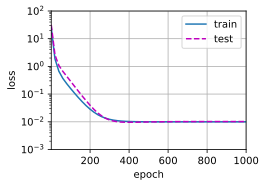

In [14]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.2992175 3.6079612]]


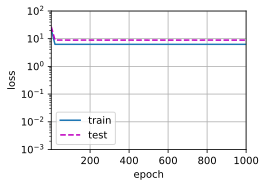

In [15]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.9741049e+00  1.2188917e+00 -3.2270770e+00  5.3671236e+00
  -5.1648265e-01  1.2007672e+00 -1.0728663e-01  2.2531311e-01
   2.6281144e-02 -1.5038221e-01 -3.1765360e-02 -5.6874128e-03
  -1.5943603e-01  3.6747276e-03  1.7301716e-01 -3.6581546e-02
  -6.4904451e-02  6.4389944e-02  1.1050090e-02 -1.5771243e-01]]


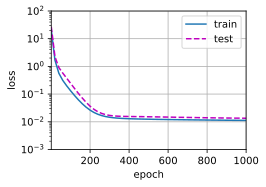

In [13]:
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:])

weight: [[ 4.937581    1.2396734  -3.052754    5.3163867  -1.0411843   1.3029056
  -0.1086348   0.04252928  0.17782773  0.05885199  0.0057899  -0.20369793
  -0.02107358  0.09505633 -0.2157347   0.17293572 -0.17117094 -0.19976366
   0.11908719  0.03131309]]


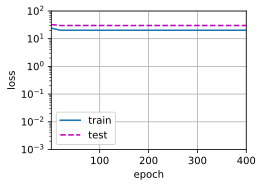

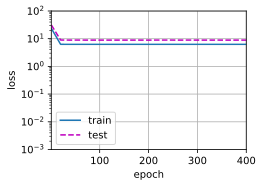

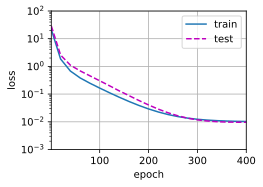

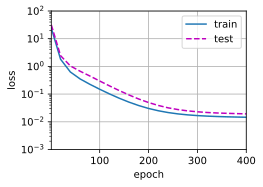

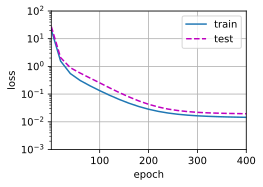

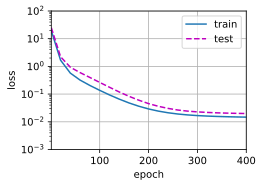

In [18]:
def mse_from_degree(degree):
    train(poly_features[:n_train, :degree], poly_features[n_train:, :degree],
          labels[:n_train], labels[n_train:])

for i in [1, 2, 4, 6, 10, 20]:
    mse_from_degree(i)